# Filter Data for Efrat

Load the raw dataframe, show the row data, and drop rainfall-related columns.

In [1]:
import os
import pandas as pd

SIM_DIR = r"D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change\pickles\Urbanization_comparsion"
OUTPUT_DIR = r"D:\Development\RESEARCH\Raanana\data"
EVENT_NUMBERS = {5, 6, 13, 20, 21, 22, 27, 39}
SCENARIOS = [
    "38% urbanization",
    "73% urbanization",
    "87% urbanization",
]
PREVIEW_SCENARIO = "87% urbanization"
PKL_MAP = {
    '38% urbanization': 'urbanization_1_0.pkl',
    '42% urbanization': 'urbanization_1_1.pkl',
    '46% urbanization': 'urbanization_1_2.pkl',
    '49% urbanization': 'urbanization_1_3.pkl',
    '53% urbanization': 'urbanization_1_4.pkl',
    '57% urbanization': 'urbanization_1_5.pkl',
    '73% urbanization': 'urbanization_2_0.pkl',
    '81% urbanization': 'urbanization_3_0.pkl',
    '83% urbanization': 'urbanization_4_0.pkl',
    '87% urbanization': 'urbanization_5_0.pkl',
}

def column_text(col):
    if isinstance(col, tuple):
        return " ".join(str(part) for part in col if part is not None).lower()
    return str(col).lower()

def is_rainfall_column(col):
    text = column_text(col)
    return any(keyword in text for keyword in ("rainfall", "precip", "rain", "intensity", "outflow_time", "flow_time", "max_flow_time"))

def event_mask(series):
    numeric_values = pd.to_numeric(series, errors="coerce")
    mask = numeric_values.isin(EVENT_NUMBERS)
    if mask.any():
        return mask
    return series.astype(str).str.strip().isin({str(number) for number in EVENT_NUMBERS})

def save_scenario_outputs(scenario):
    pkl_path = os.path.join(SIM_DIR, PKL_MAP[scenario])
    raw_df = pd.read_pickle(pkl_path)
    event_col = next(col for col in raw_df.columns if "event" in column_text(col) and "num" in column_text(col))
    selected_df = raw_df.loc[~event_mask(raw_df[event_col])].copy()
    rainfall_columns = [col for col in selected_df.columns if is_rainfall_column(col)]
    clean_df = selected_df.drop(columns=rainfall_columns)

    print(f"Loaded scenario: {scenario}")
    print(f"Raw shape: {raw_df.shape}")
    print(f"Remaining rows after excluding events: {clean_df.shape}")
        # print("Events kept:")
    print("Events excluded:")
    print(sorted(EVENT_NUMBERS))
    print("Rainfall-related columns removed:")
    for col in rainfall_columns:
        print(col)

    event_data = clean_df.drop(columns=[col for col in [event_col] if col is not None])
    y_col = next((col for col in event_data.columns if column_text(col) == "y"), None)
    event_data = event_data.drop(columns=[col for col in [y_col] if col is not None])
    event_data = event_data.drop(columns=[col for col in event_data.columns if (col[0] if isinstance(col, tuple) else str(col)).lower() in {"x", "y", "d"}], errors="ignore")
    numeric_cols = event_data.select_dtypes(include="number").columns
    event_stats = event_data.groupby(clean_df[event_col])[numeric_cols].agg(["max", "min", "median"]) if len(numeric_cols) else pd.DataFrame()

    scenario_tag = scenario.split("%")[0].strip()
    row_output_path = os.path.join(OUTPUT_DIR, f"efrat_row_discharge_results_{scenario_tag}urbanization_level.csv")
    stats_output_path = os.path.join(OUTPUT_DIR, f"efrat_event_stats_{scenario_tag}urbanization_level.csv")
    clean_df.to_csv(row_output_path, index=False)
    event_stats.to_csv(stats_output_path)

    print(f"Saved filtered dataframe to: {row_output_path}")
    print(f"Saved event stats to: {stats_output_path}")
    print(f"Summary shape: {event_stats.shape}")
    print("Columns sampled:")
    for name in list(event_stats.columns[:12]):
        print(name)

    return {
        "raw_df": raw_df,
        "clean_df": clean_df,
        "event_stats": event_stats,
        "event_col": event_col,
        "rainfall_columns": rainfall_columns,
        "row_output_path": row_output_path,
        "stats_output_path": stats_output_path,
    }

os.makedirs(OUTPUT_DIR, exist_ok=True)
scenario_results = {scenario: save_scenario_outputs(scenario) for scenario in SCENARIOS}

preview_result = scenario_results[PREVIEW_SCENARIO]
raw_df = preview_result["raw_df"]
clean_df = preview_result["clean_df"]
event_stats = preview_result["event_stats"]
event_col = preview_result["event_col"]
rainfall_columns = preview_result["rainfall_columns"]
print(f"Preview scenario: {PREVIEW_SCENARIO}")

Loaded scenario: 38% urbanization
Raw shape: (3444, 96)
Remaining rows after excluding events: (2772, 34)
Events excluded:
[5, 6, 13, 20, 21, 22, 27, 39]
Rainfall-related columns removed:
('historical', 'basin discharge', 'swmm_max_outflow_time')
('historical', 'full_basin', 'max_10min_intensity')
('historical', 'full_basin', 'max_20min_intensity')
('historical', 'full_basin', 'max_30min_intensity')
('historical', 'full_basin', 'max_60min_intensity')
('historical', 'full_basin', 'max_120min_intensity')
('historical', 'full_basin', 'max_240min_intensity')
('historical', 'full_basin', 'max_360min_intensity')
('historical', 'full_basin', 'max_720min_intensity')
('historical', 'full_basin', 'max_1440min_intensity')
('historical', 'full_basin', 'total_rain')
('historical', 'before_peak', 'max_10min_intensity')
('historical', 'before_peak', 'max_20min_intensity')
('historical', 'before_peak', 'max_30min_intensity')
('historical', 'before_peak', 'max_60min_intensity')
('historical', 'before_p

In [2]:
print("Raw row data:")
print(raw_df.head(10).to_string(index=False))


Raw row data:
event_num x      y       d      historical                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           future                                                               

In [3]:

print("\nFiltered row data:")
print(clean_df.head(10).to_string(index=False))


Filtered row data:
event_num x      y       d      historical                                                                                                                                                                                                                                                                    future                                                                                                                                                                                                                                                          
                           basin discharge                                  Max_Specific_Discharge                                    Min_Specific_Discharge                                    Most_Urban_S27                                    Least_Urban_S28                                    basin discharge                                  Max_Specific_Discharge                                    Min_Specific_Discharg

In [4]:
print("Saved outputs for all requested scenarios:")
for scenario in SCENARIOS:
    result = scenario_results[scenario]
    print(f"{scenario}:")
    print(f"  {result['row_output_path']}")
    print(f"  {result['stats_output_path']}")


Saved outputs for all requested scenarios:
38% urbanization:
  D:\Development\RESEARCH\Raanana\data\efrat_row_discharge_results_38urbanization_level.csv
  D:\Development\RESEARCH\Raanana\data\efrat_event_stats_38urbanization_level.csv
73% urbanization:
  D:\Development\RESEARCH\Raanana\data\efrat_row_discharge_results_73urbanization_level.csv
  D:\Development\RESEARCH\Raanana\data\efrat_event_stats_73urbanization_level.csv
87% urbanization:
  D:\Development\RESEARCH\Raanana\data\efrat_row_discharge_results_87urbanization_level.csv
  D:\Development\RESEARCH\Raanana\data\efrat_event_stats_87urbanization_level.csv


CDF scenario: 38% urbanization
Peak discharge location: basin discharge
Historical column: ('historical', 'basin discharge', 'max_discharge')
Future column: ('future', 'basin discharge', 'max_discharge')
CDF scenario: 73% urbanization
Peak discharge location: basin discharge
Historical column: ('historical', 'basin discharge', 'max_discharge')
Future column: ('future', 'basin discharge', 'max_discharge')
CDF scenario: 87% urbanization
Peak discharge location: basin discharge
Historical column: ('historical', 'basin discharge', 'max_discharge')
Future column: ('future', 'basin discharge', 'max_discharge')


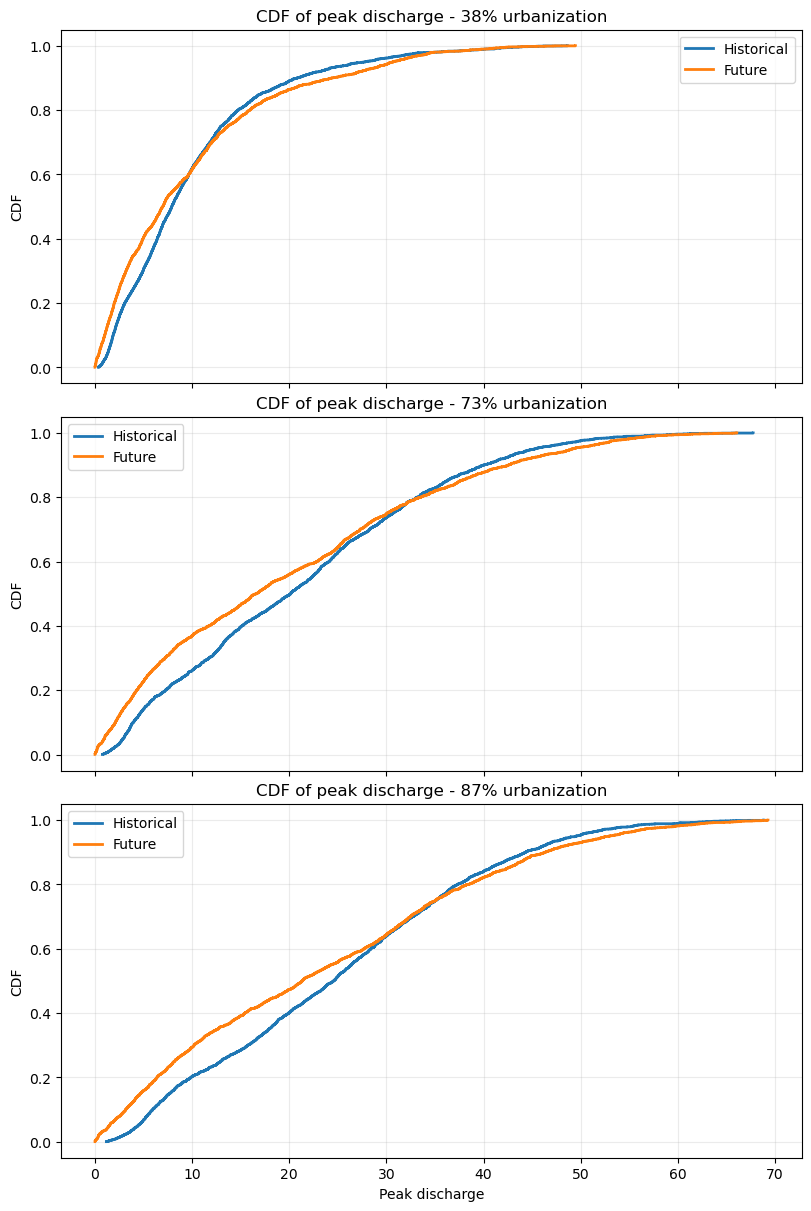

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def find_peak_discharge_columns(df):
    preferred_locations = ["basin discharge", "Max_Specific_Discharge"]
    for location in preferred_locations:
        hist_col = next(
            (
                col
                for col in df.columns
                if isinstance(col, tuple)
                and len(col) >= 3
                and col[0] == "historical"
                and col[1] == location
                and col[2] == "max_discharge"
            ),
            None,
        )
        fut_col = next(
            (
                col
                for col in df.columns
                if isinstance(col, tuple)
                and len(col) >= 3
                and col[0] == "future"
                and col[1] == location
                and col[2] == "max_discharge"
            ),
            None,
        )
        if hist_col is not None and fut_col is not None:
            return location, hist_col, fut_col
    return None, None, None

def ecdf(values):
    clean_values = pd.Series(values).dropna().astype(float).sort_values().to_numpy()
    if clean_values.size == 0:
        return clean_values, clean_values
    y_values = np.arange(1, clean_values.size + 1) / clean_values.size
    return clean_values, y_values

fig, axes = plt.subplots(len(SCENARIOS), 1, figsize=(8, 4 * len(SCENARIOS)), sharex=True, constrained_layout=True)
if len(SCENARIOS) == 1:
    axes = [axes]

for ax, scenario in zip(axes, SCENARIOS):
    df = scenario_results[scenario]["clean_df"]
    location_name, hist_col, fut_col = find_peak_discharge_columns(df)
    if hist_col is None or fut_col is None:
        ax.text(0.5, 0.5, f"No peak discharge columns found for {scenario}", ha="center", va="center")
        ax.set_axis_off()
        continue

    hist_x, hist_y = ecdf(df[hist_col])
    fut_x, fut_y = ecdf(df[fut_col])

    ax.step(hist_x, hist_y, where="post", label="Historical", linewidth=2)
    ax.step(fut_x, fut_y, where="post", label="Future", linewidth=2)
    ax.set_title(f"CDF of peak discharge - {scenario}")
    ax.set_ylabel("CDF")
    ax.grid(True, alpha=0.25)
    ax.legend()
    print(f"CDF scenario: {scenario}")
    print(f"Peak discharge location: {location_name}")
    print(f"Historical column: {hist_col}")
    print(f"Future column: {fut_col}")

axes[-1].set_xlabel("Peak discharge")
plt.show()


In [5]:
# Summarize each event once per historical/future location.
# For every numeric parameter, compute max/min/median across all rows of the same event.
event_col = next(col for col in clean_df.columns if "event" in column_text(col) and "num" in column_text(col))
y_col = next((col for col in clean_df.columns if column_text(col) == "y"), None)

summary_source = clean_df.drop(columns=[col for col in [event_col, y_col] if col is not None])
summary_source = summary_source.drop(columns=[col for col in summary_source.columns if (col[0] if isinstance(col, tuple) else str(col)).lower() in {"x", "y", "d"}], errors="ignore")
numeric_cols = summary_source.select_dtypes(include="number").columns

event_stats = summary_source.groupby(clean_df[event_col])[numeric_cols].agg(["max", "min", "median"])

scenario_tag = PREVIEW_SCENARIO.split("%")[0].strip()
summary_output_path = os.path.join(OUTPUT_DIR, f"efrat_event_stats_{scenario_tag}urbanization_level.csv")
event_stats.to_csv(summary_output_path)

print(f"Saved event stats to: {summary_output_path}")
print(f"Summary shape: {event_stats.shape}")
print("Columns sampled:")
for name in list(event_stats.columns[:12]):
    print(name)


Saved event stats to: D:\Development\RESEARCH\Raanana\data\efrat_event_stats_87urbanization_level.csv
Summary shape: (33, 90)
Columns sampled:
('historical', 'basin discharge', 'total_discharge', 'max')
('historical', 'basin discharge', 'total_discharge', 'min')
('historical', 'basin discharge', 'total_discharge', 'median')
('historical', 'basin discharge', 'max_discharge', 'max')
('historical', 'basin discharge', 'max_discharge', 'min')
('historical', 'basin discharge', 'max_discharge', 'median')
('historical', 'basin discharge', 'runoff_coefficient', 'max')
('historical', 'basin discharge', 'runoff_coefficient', 'min')
('historical', 'basin discharge', 'runoff_coefficient', 'median')
('historical', 'Max_Specific_Discharge', 'max_discharge', 'max')
('historical', 'Max_Specific_Discharge', 'max_discharge', 'min')
('historical', 'Max_Specific_Discharge', 'max_discharge', 'median')


Scatter location: basin discharge
Scatter metrics: ['total_discharge', 'max_discharge', 'runoff_coefficient']


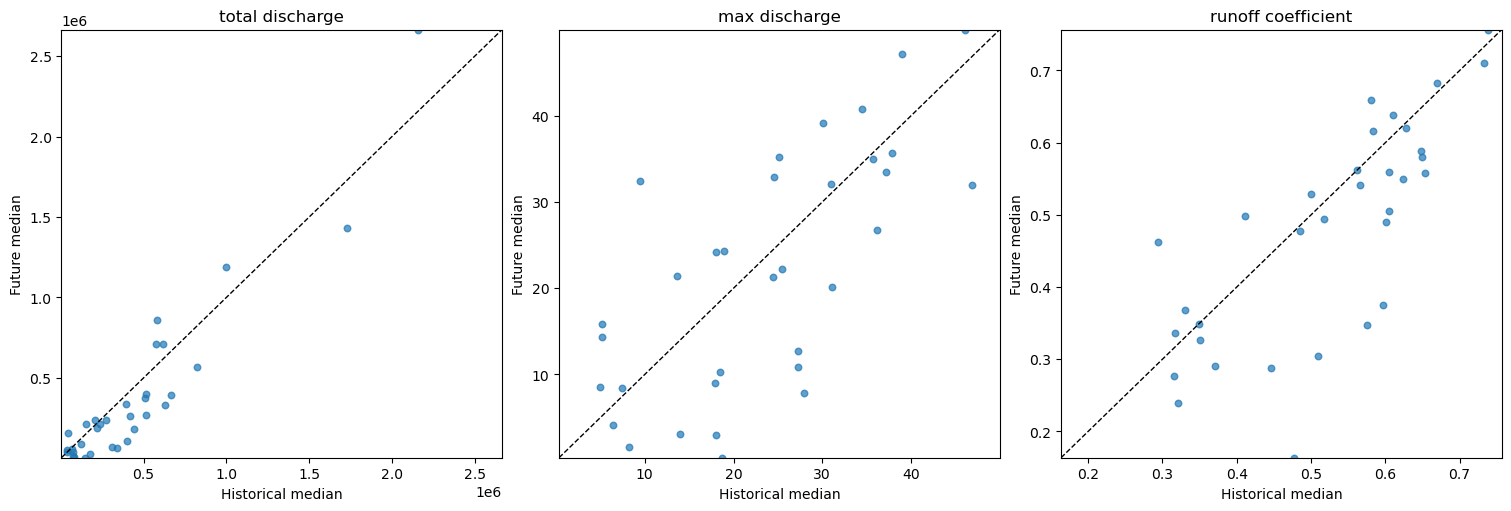

In [6]:
# Scatter plot of historical vs future median values for a few shared parameters.
import numpy as np
import matplotlib.pyplot as plt
median_stats = event_stats.xs("median", axis=1, level=-1)

preferred_locations = ["basin discharge", "Max_Specific_Discharge"]
preferred_metrics = ["total_discharge", "max_discharge", "runoff_coefficient"]

def pick_column(df, scenario, location, metric):
    for col in df.columns:
        if isinstance(col, tuple) and len(col) >= 3 and col[0] == scenario and col[1] == location and col[2] == metric:
            return col
    return None

location_name = None
for candidate_location in preferred_locations:
    if any(pick_column(median_stats, "historical", candidate_location, metric) is not None and pick_column(median_stats, "future", candidate_location, metric) is not None for metric in preferred_metrics):
        location_name = candidate_location
        break

if location_name is None:
    print("No shared historical/future location was found for the scatter plot.")
else:
    selected_metrics = [metric for metric in preferred_metrics if pick_column(median_stats, "historical", location_name, metric) is not None and pick_column(median_stats, "future", location_name, metric) is not None]
    selected_metrics = selected_metrics[:3]
    if not selected_metrics:
        print(f"No shared metrics found for {location_name}.")
    else:
        fig, axes = plt.subplots(1, len(selected_metrics), figsize=(5 * len(selected_metrics), 5), constrained_layout=True)
        if len(selected_metrics) == 1:
            axes = [axes]
        for ax, metric in zip(axes, selected_metrics):
            hist_col = pick_column(median_stats, "historical", location_name, metric)
            fut_col = pick_column(median_stats, "future", location_name, metric)
            x = median_stats[hist_col]
            y = median_stats[fut_col]
            ax.scatter(x, y, s=22, alpha=0.7)
            lim_min = np.nanmin([x.min(), y.min()])
            lim_max = np.nanmax([x.max(), y.max()])
            ax.plot([lim_min, lim_max], [lim_min, lim_max], "k--", lw=1)
            ax.set_title(metric.replace("_", " "))
            ax.set_xlabel("Historical median")
            ax.set_ylabel("Future median")
            ax.set_xlim(lim_min, lim_max)
            ax.set_ylim(lim_min, lim_max)
        print(f"Scatter location: {location_name}")
        print(f"Scatter metrics: {selected_metrics}")
        plt.show()
